# 휴먼 인 더 루프 반영하기

In [ ]:
# 워크플로 실행중 사람의 개입이 필요한 경우도 있다.
# ex) 중간결과에 대해 사람의 판단을 요구
# ex) 사람이 힌트를 준다든가..

# 이러한 것을 Human-In-The-Loop 라 한다.

# Human-In-The-Loop 는 보통 다음과 같은 4단계로 구성
# 1. 중단점(Breakpoint) : AI가 인간의 개입이 필요한 지점을 인식
# 2. 컨텍스트 제공: 인간이 올바른 결정을 내릴 수 있도록 충분한 정보 제공
# 3. 피드백 수집 : 구조화된 방식으로 인간의 입력 수집
# 4. 재개(Resume) : 인간의 결정에 따라 워크플로 계속 진행


![](https://www.dropbox.com/scl/fi/po3ii19nb6fchl8b66mj5/1168f532-b747-40f3-9df2-5e9648e44fa8.png?rlkey=02sq0845nwsav6qffu131clb0&st=ozw31z4h&dl=1)
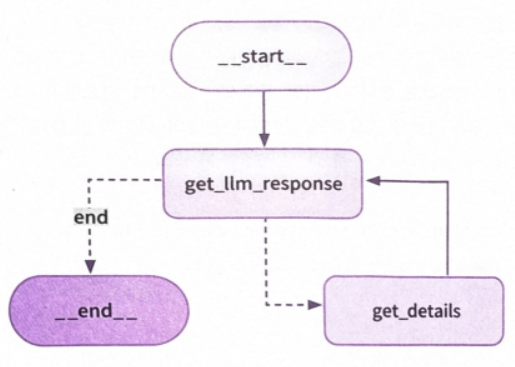

![](https://www.dropbox.com/scl/fi/oi4tdj35n49xgpjry5loj/f193e900-defc-4b93-b918-3b767d5d0102.png?rlkey=061643znz2qacakwrc5jz5et8&st=2qnzy4nq&dl=1)
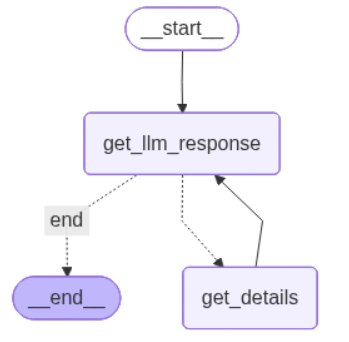

# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Literal
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from IPython.display import Image, display

True


# State 정의

In [2]:
# Pydantic을 사용한 State 정의
class AgentState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 작업")
    task_details: str = Field(default="", description="작업 상세 정보")
    response: str = Field(default="", description="응답 결과")
    

# 노드 함수 정의

In [ ]:
# 사용자가 상세정보를 제공했다면 최종 보고서를 생성하고, 
# 그렇지 않다면 LLM이 사용자에게 추가 정보를 요청하도록 프롬프트를 구성합니다. 
# 이 노드는 상태의 task_details 필드를 확인하여 현재 대화의 단계를 파악하고 적절한 응답을 생성합니다.


In [3]:
# ① 노드 함수 정의
def get_llm_response_node(state: AgentState, llm):
    """LLM과 상호작용하여 응답을 생성하거나, 추가 정보를 요청하는 노드"""
    
    # task_details 필드 확인
    details = state.task_details

    if details:
        print(f"\n상세 정보를 바탕으로 작업 실행: '{details}'")
        prompt = f"다음 요청에 따라 보고서를 작성해주세요: {details}"
    else:
        task = state.user_message
        print(f"\n작업 실행: '{task}' 작업을 수행합니다...")

        # ② LLM에게 상세 정보를 묻는 질문을 하도록 유도하고, 반드시 '?'로 끝내도록 지시
        #  : 프롬프트 엔지니어링을 사용하여 LLM의 응답을 제어합니다. 물음표로 끝나도록 명시적으로 지시함으로써, 
        #   후속조건부 분기에서 LLM이 추가 정보를 요청하는지 아니면 최종 결과를 생성했는지를 명확하게 구분할 수 있습니다.
        prompt = f"""
            '{task}' 작업을 수행하려고 합니다. 어떤 종류의 보고서가 필요한지, 구체적인 주제는 무엇인지 질문해주세요. 
            추가 정보가 필요하면, 반드시 응답의 마지막을 물음표('?')로 끝내주세요.
        """        

    response = llm.invoke(prompt).content
    
    print("--- LLM 응답 ---")
    print(response)
    print("--------------------")

    return {"response": response, "task_details": ""}    
    

# 사람의 입력을 받는 노드

In [ ]:
# 휴먼 인 더 루프의 핵심 구현부로, 워크플로 실행을 일시 중지하고 사용자의 입력을 대기합니다. 
# LLM이 요청한 추가 정보를 사용자로부터 수집하여 task_details필드에 저장합니다. 
# 이 노드는 AI와 인간 간의 대화형 상호작용을 가능하게 하는 다리 역할을 합니다.


In [4]:
# ③ 사람의 입력을 받는 노드
def get_task_details_node(state: AgentState) -> AgentState:
    """LLM의 질문에 대한 사용자 답변을 입력받는 노드"""
    print("\nLLM의 질문에 답변해주세요.")
    user_input = input("답변: ")
    return {"task_details": user_input}

# 조건부 분기 노드

In [5]:
# LLM 응답 패턴 분석하여 다음 경로 결정
# "? 물음표" 로 끝나면 get_details 노드로 분기
#            그렇지 앟으면 워크플로 종료


In [6]:
# ④ 조건부 분기 노드
def check_llm_response(state: AgentState) -> Literal["get_details", "end"]:
    """LLM의 응답이 질문인지 확인하여 다음 단계를 결정합니다."""
    print("LLM 응답 분석 중...")

    if state.response.strip().endswith("?"):
        print("LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.")
        return "get_details"
        
    print("최종 보고서가 생성되었습니다. 워크플로우를 종료합니다.")
    return "end"
    

# 그래프 생성
워크플로 생성

In [7]:
# ⑤ 그래프 생성
def create_graph():
    """Human-in-the-loop 워크플로우 그래프를 생성합니다."""
    # 그래프 전체에서 사용할 LLM 모델을 초기화합니다.
    llm = init_chat_model('gpt-4o', model_provider='openai')

    def get_llm_response_with_llm(state):  # State 하나 받는 함수. 노드로 사용 가능!
        return get_llm_response_node(state, llm)

    # node 추가
    workflow = StateGraph(AgentState)
    workflow.add_node("get_llm_response", get_llm_response_with_llm)
    workflow.add_node("get_details", get_task_details_node)
    
    # edge 추가
    workflow.add_edge(START, "get_llm_response")
    workflow.add_conditional_edges(
        "get_llm_response",
        check_llm_response,
        {
            "get_details": "get_details",
            "end": END
        }
    )
    workflow.add_edge("get_details", "get_llm_response")
    
    return workflow.compile()

# 실행

In [8]:
def main():
    print("=== LangGraph Human-in-the-loop 간소화 예제 ===\n")
    app = create_graph()

    final_state = app.invoke(AgentState(user_message="블로그 글 작성"))
    
    print("\n--- 워크플로우 종료 ---")
    print("최종 응답:")
    print(final_state["response"])


if __name__ == "__main__":
    main()


=== LangGraph Human-in-the-loop 간소화 예제 ===


작업 실행: '블로그 글 작성' 작업을 수행합니다...
--- LLM 응답 ---
블로그 글 작성을 위한 보고서 유형에 따라 필요한 정보가 다를 수 있습니다. 작성하려는 블로그 글의 목표는 무엇인가요? 특정한 주제나 키워드가 있다면 공유해 주실 수 있나요? 블로그의 대상 독자는 누구인가요? 이를 통해 적절한 조사를 도울 수 있습니다. 추가 정보가 필요하시다면 알려주세요?
--------------------
LLM 응답 분석 중...
LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.

LLM의 질문에 답변해주세요.


답변:  서울의 맛집 블로그



상세 정보를 바탕으로 작업 실행: '서울의 맛집 블로그'
--- LLM 응답 ---
서울은 다양한 맛집들이 모여 있는 미식의 도시로, 전통 한식부터 현대적인 퓨전 요리까지 다양한 음식을 즐길 수 있습니다. 아래는 서울에서 꼭 방문해봐야 할 몇 가지 맛집 블로그에 소개될 만한 곳들입니다.

### 1. 한식 맛집
- **명동교자**: 1966년에 문을 연 명동교자는 칼국수와 만두로 유명합니다. 명동에 위치하고 있어 관광객들에게 인기가 많습니다. 이곳의 면발은 쫄깃하고 국물은 깊고 진한 맛을 자랑합니다.

- **토속촌 삼계탕**: 삼계탕을 전문으로 하는 이곳은 닭 안에 찹쌀, 인삼, 대추 등을 넣어 푹 고아낸 국물 요리가 일품입니다. 특히 여름철 보양식으로 많은 사랑을 받고 있습니다.

### 2. 현대 한식 & 퓨전
- **정식당**: 미쉐린 스타를 받은 레스토랑으로, 전통 한식을 현대적으로 재해석한 요리로 유명합니다. 깔끔하고 세련된 분위기에서 특별한 식사를 경험할 수 있습니다.

- **광장시장 마약김밥**: 간단한 길거리 음식이지만, 광장시장 마약김밥은 아주 매력적인 맛을 자랑합니다. 단무지와 당근이 들어간 김밥은 중독적인 맛을 느낄 수 있습니다.

### 3. 디저트 & 카페
- **오설록 티하우스**: 제주산 녹차로 만든 다양한 디저트를 맛볼 수 있는 곳입니다. 녹차 아이스크림과 롤케이크가 특히 인기입니다. 차분한 분위기에서 여유로운 티타임을 즐기기 좋습니다.

- **빨간머리 앤 베이커리**: 앤 셜리의 낭만이 느껴지는 공간에서 신선한 빵과 디저트를 즐길 수 있습니다. 매일 아침 갓 구워내는 빵은 언제나 인기 만점입니다.

### 4. 글로벌 요리
- **엘본 더 테이블**: 프렌치 레스토랑으로, 창의적인 메뉴와 고급스러운 서비스로 잘 알려져 있습니다. 인상적인 플레이팅과 함께 정교한 요리를 맛볼 수 있습니다.

- **사이닉 한남**: 이탈리안 요리를 전문으로 하는 레스토랑으로, 신선한 재료로 만든 피자와 파스타가 일품입니다. 한남동의 트렌디한 